In [1]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

In [2]:
# patch transformation
in_channels = 3
patch_size = 8
# 64x3 out channels for 3x8x8 image patches
patch_arr = torch.reshape(torch.eye(patch_size**2), (patch_size**2, patch_size, patch_size))
patch_weights = torch.zeros((in_channels * patch_size**2, in_channels, patch_size, patch_size))
for i in range(in_channels * patch_size**2):
    patch_weights[i, i % in_channels] = patch_arr[i // in_channels]
patch_weights.to(dtype=torch.float32)
print(patch_weights.dtype)
print(patch_weights.shape)
patch_filter = nn.Conv2d(in_channels, in_channels * patch_size**2, patch_size, stride=patch_size, padding=0, bias=False)
patch_filter.weight = nn.Parameter(patch_weights)
patch_filter.weight.requires_grad = False

torch.float32
torch.Size([192, 3, 8, 8])


In [3]:
class PatchConv(nn.Module):
    def __init__(self, in_channels, patch_size):
        super(PatchConv, self).__init__()
        patch_arr = torch.reshape(torch.eye(patch_size**2), (patch_size**2, patch_size, patch_size))
        patch_weights = torch.zeros((in_channels * patch_size**2, in_channels, patch_size, patch_size))
        for i in range(in_channels * patch_size**2):
            patch_weights[i, i % in_channels] = patch_arr[i // in_channels]
        patch_weights.to(dtype=torch.float32)
        self.patch_filter = nn.Conv2d(in_channels, in_channels * patch_size**2, patch_size, stride=patch_size, padding=0, bias=False)
        self.patch_filter.weight = nn.Parameter(patch_weights)
        self.patch_filter.weight.requires_grad = False
    
    def forward(self, x):
        return self.patch_filter(x)

In [4]:
# Absolute Position Encoding (32 channels)
def gen_ape(num_channels, img_size):
    num_channels = torch.tensor(num_channels) # must be a multiple of 4 to have sin & cos for both x and y axes
    img_size = torch.tensor(img_size)
    NQ = torch.tensor(4)

    varying_dim = torch.linspace(0, img_size-1, steps=img_size)
    static_dim = torch.linspace(0, 0, steps=img_size)
    wavelength_dim = torch.linspace(torch.log(NQ)/torch.log(img_size), 1, steps=num_channels//4)
    wavelength_dim = torch.pow(img_size, wavelength_dim)

    # make first dim position encoding
    grid_tuple = torch.meshgrid(wavelength_dim, varying_dim, static_dim, indexing='ij')
    dim1_ape = torch.concat(\
                        (torch.sin((1 /  grid_tuple[0]) * grid_tuple[1] * 2*torch.pi), 
                            torch.cos((1 /  grid_tuple[0]) * grid_tuple[1] * 2*torch.pi)) )
    # make second dim position encoding
    grid_tuple = torch.meshgrid(wavelength_dim, static_dim, varying_dim, indexing='ij')
    dim2_ape = torch.concat(\
                        (torch.sin((1 /  grid_tuple[0]) * grid_tuple[2] * 2*torch.pi), 
                            torch.cos((1 /  grid_tuple[0]) * grid_tuple[2] * 2*torch.pi)) )
    ape = torch.concat((dim1_ape, dim2_ape))
    return ape

In [5]:
ape1 = gen_ape(32, 128)
print(ape1.shape)

torch.Size([32, 128, 128])


In [6]:
def visualize(map):
    zero_map = torch.zeros((1,)+map.shape[1:])
    s_transformed = (map + 1)/2
    if map.shape[0] == 1:
        return torch.permute(torch.concat((s_transformed, zero_map, zero_map)), (1, 2, 0))
    elif map.shape[0] == 2:
        return torch.permute(torch.concat((s_transformed, zero_map)), (1, 2, 0))

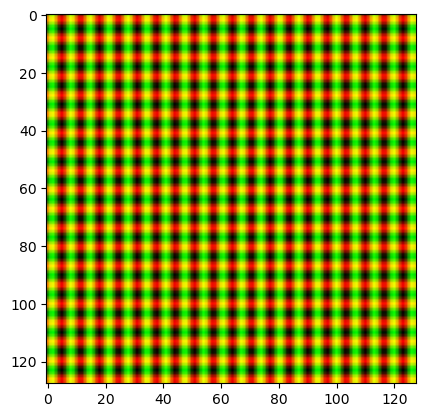

In [7]:
plt.imshow(visualize(torch.stack((ape1[1, :, :], ape1[17, :, :]) )) )

In [8]:
m = torch.Tensor([[1, 2], [3, 4]])
batch = torch.Tensor([[[1, 0], [0, 1]], [[1, 1], [-1, -1]]])
torch.matmul(batch, m)

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 4.,  6.],
         [-4., -6.]]])

In [9]:
torch.randn(5, 2)

tensor([[ 0.2540,  1.1325],
        [-0.9342,  0.5086],
        [ 0.4783, -0.4163],
        [ 0.6381, -1.1504],
        [-1.0969,  0.5088]])

In [10]:
m = torch.Tensor([[[1, 2], [3, 4], [6, 7]], [[5, 6], [7, 8], [6, 7]], [[9, 10], [11, 12], [1, 1]]])
n = torch.Tensor([[[1, -1], [-1, 1], [0, 0]], [[1, 0], [0, 1], [0, 0]], [[1, 0], [0, 1], [0, 0]]])
torch.matmul(m, torch.permute(n, (0, 2, 1)))

tensor([[[-1.,  1.,  0.],
         [-1.,  1.,  0.],
         [-1.,  1.,  0.]],

        [[ 5.,  6.,  0.],
         [ 7.,  8.,  0.],
         [ 6.,  7.,  0.]],

        [[ 9., 10.,  0.],
         [11., 12.,  0.],
         [ 1.,  1.,  0.]]])

In [11]:
class ResidualNorm(nn.Module):
    def __init__(self, inchannels, outchannels):
        super(ResidualNorm, self).__init__()

        self.res_conv = nn.Conv2d(inchannels, outchannels, 1, stride=1, padding=0, bias=False)
        self.layer_norm = nn.LayerNorm(outchannels)

    def forward(self, x_orig, x):
        res_image = x + self.res_conv(x_orig)
        out_image = torch.permute(self.layer_norm(torch.permute(res_image, (0, 2, 3, 1))), (0, 3, 1, 2))
        return out_image


In [28]:
class Residual(nn.Module):
    def __init__(self, inchannels, outchannels):
        super(Residual, self).__init__()

        self.res_conv = nn.Conv2d(inchannels, outchannels, 1, stride=1, padding=0, bias=False)

    def forward(self, x_orig, x):
        res_image = x + self.res_conv(x_orig)
        return res_image

In [29]:
class MLP(nn.Module):
    def __init__(self, inchannels, outchannels, num_layers=3):
        super(MLP, self).__init__()

        conv_layers = []
        for i in range(num_layers):
            endchannels = outchannels if (i == num_layers-1) else inchannels
            conv_layers.append(nn.Conv2d(inchannels, endchannels, 1, stride=1, padding=0, bias=True))
            conv_layers.append(nn.LeakyReLU())

        self.conv_layers = nn.Sequential(*conv_layers)
        self.res = Residual(inchannels, outchannels)

    def forward(self, x):
        return self.res(x, self.conv_layers(x))


In [30]:
class SameSizeConv(nn.Module):
    def __init__(self, inchannels, outchannels, p_dropout, num_layers=2):
        super(SameSizeConv, self).__init__()
        self.p_dropout = p_dropout
        
        self.kernelSize = 5
        convs = []

        for _ in range(num_layers):
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize, stride=1, \
                    padding=(self.kernelSize-1)//2, bias=False) )
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize+2, stride=1, \
                    dilation=2, padding=(self.kernelSize+2-1), bias=False) )
            convs.append(nn.BatchNorm2d(inchannels))
            convs.append(nn.LeakyReLU())
            convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, inchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, outchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(outchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))

        self.res_conv = nn.Conv2d(inchannels, outchannels, 1, stride=1, padding=0, bias=False)
        
        self.conv_layers = nn.Sequential(*convs)
    
    def forward(self, x):
        return (self.conv_layers(x) + self.res_conv(x))/2

In [31]:
class VisionAttention(nn.Module):
    def __init__(self, image_size, inchannels, qkchannels, vchannels):
        super(VisionAttention, self).__init__()

        # need to know how to customize initialization broadly
        self.image_size = image_size
        self.qkchannels = qkchannels
        self.qkscalar = torch.sqrt(torch.tensor(self.qkchannels))
        
        self.vchannels = vchannels
        self.queryMatrix = nn.Parameter(torch.empty(inchannels, qkchannels), requires_grad=True)
        self.keyMatrix = nn.Parameter(torch.empty(inchannels, qkchannels), requires_grad=True)
        self.valueMatrix = nn.Parameter(torch.empty(inchannels, vchannels), requires_grad=True)
        self.ape = torch.permute(torch.flatten(gen_ape(qkchannels, self.image_size), start_dim=1, end_dim=2), (1, 0))

        self.res = ResidualNorm(inchannels, vchannels)

        self.mlp = MLP(vchannels, vchannels)
    
    def forward(self, x): # x should be of dimension (batch, channels, imx, imy) ->(batch, length of sequence, dimension of embedding)
        x_seq = torch.flatten(torch.permute(x, (0, 2, 3, 1)), start_dim=1, end_dim=2)
        queries = torch.matmul(x_seq+self.ape, self.queryMatrix)
        keys = torch.matmul(x_seq+self.ape, self.keyMatrix)
        values = torch.matmul(x_seq, self.valueMatrix)
        cosine_sim = torch.matmul(queries, torch.permute(keys, (0, 2, 1))) / self.qkscalar
        attention = F.softmax(cosine_sim, dim=2) # dimension 2 contains all dot products for one query and all keys
        values = torch.matmul(attention, values)
        values_image = torch.unflatten(torch.permute(values, (0, 2, 1)), dim=2, sizes=(self.image_size, self.image_size))

        out_image = self.res(x, values_image)

        mlp_image = self.mlp(out_image)

        return mlp_image

In [32]:
# class MultiHeadVisionAttention(nn.Module):
#     def __init__(self, image_size, inchannels, outchannels, numheads):
#         super(MultiHeadVisionAttention, self).__init__()

#         self.numheads = numheads
#         self.heads = []
#         for i in range(numheads):
#             self.heads.append(VisionAttention(image_size, inchannels, inchannels, outchannels))

#         self.combine = nn.Conv2d(outchannels*numheads, outchannels, 1, stride=1, padding=0, bias=False)

#     def forward(self, x):
#         # find a way to parallelize later
#         out = torch.concat([self.heads[i](x) for i in range(self.numheads)], dim=1)
#         return self.combine(out)
        


In [56]:
class MultiHeadVisionAttention(nn.Module):
    def __init__(self, image_size, inchannels, qkchannels, vchannels, numheads):
        super(MultiHeadVisionAttention, self).__init__()

        # need to know how to customize initialization broadly
        self.image_size = image_size
        self.qkchannels = qkchannels
        self.qkscalar = torch.sqrt(torch.tensor(self.qkchannels))
        self.numheads = numheads
        
        self.vchannels = vchannels
        self.queryMatrix = nn.Parameter(torch.empty(numheads, inchannels, qkchannels), requires_grad=True)
        #self.register_parameter(name='queryMatrix', param=nn.Parameter(torch.empty(numheads, inchannels, qkchannels), requires_grad=True))
        self.keyMatrix = nn.Parameter(torch.empty(numheads, inchannels, qkchannels), requires_grad=True)
        #self.register_parameter(name='keyMatrix', param=nn.Parameter(torch.empty(numheads, inchannels, qkchannels), requires_grad=True))
        self.valueMatrix = nn.Parameter(torch.empty(numheads, inchannels, vchannels), requires_grad=True)
        #self.register_parameter(name='valueMatrix', param=nn.Parameter(torch.empty(numheads, inchannels, vchannels), requires_grad=True))

        self.ape = torch.permute(torch.flatten(gen_ape(qkchannels, self.image_size), start_dim=1, end_dim=2), (1, 0))

        self.combine = nn.Conv2d(vchannels*numheads, vchannels, 1, stride=1, padding=0, bias=False)

        self.res = ResidualNorm(inchannels, vchannels)

        self.mlp = MLP(vchannels, vchannels)
    
    def forward(self, x): # x should be of dimension (batch, channels, imx, imy) ->(batch, numheads, length of sequence, dimension of embedding)
        x_seq = torch.permute(torch.flatten(x, start_dim=2, end_dim=3), (0, 2, 1))
        x_seq_pos = x_seq + self.ape
        x_seq_heads = x_seq.reshape((x_seq.shape[0],)+(1,)+x_seq.shape[1:]).repeat(1, self.numheads, 1, 1)
        x_seq_pos_heads = x_seq_pos.reshape((x_seq.shape[0],)+(1,)+x_seq.shape[1:]).repeat(1, self.numheads, 1, 1)
        print("Sequence shape after head dimension ", x_seq_heads.shape)
        queries = torch.matmul(x_seq_pos_heads, self.queryMatrix)
        keys = torch.matmul(x_seq_pos_heads, self.keyMatrix)
        values = torch.matmul(x_seq_heads, self.valueMatrix)
        cosine_sim = torch.matmul(queries, torch.permute(keys, (0, 1, 3, 2))) / self.qkscalar
        attention = F.softmax(cosine_sim, dim=2) # dimension 2 contains all dot products for one query and all keys
        values = torch.matmul(attention, values)
        values_image = torch.unflatten(torch.permute(values, (0, 1, 3, 2)), dim=3, sizes=(self.image_size, self.image_size))
        print("Values image shape before head stack", values_image.shape)
        # values_image will now be of shape (batch, numheads, vchannels, image_size, image_size)
        values_image = torch.flatten(values_image, start_dim=1, end_dim=2)
        print("Values image shape after head stack", values_image.shape)
        combined = self.combine(values_image)

        out_image = self.res(x, combined)

        mlp_image = self.mlp(out_image)

        return mlp_image

In [57]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, inchannels, outchannels, numheads, numlayers):
        super(VisionTransformer, self).__init__()

        self.transformer_layers = []
        self.transformer_layers.append(PatchConv(inchannels, 8)) # image_size must be divisible by 8
        
        for i in range(numlayers):
            startchannels = inchannels*(8**2) if (i == 0) else 8**2
            endchannels = outchannels*(8**2) if (i == numlayers-1) else 8**2
            self.transformer_layers.append(MultiHeadVisionAttention(image_size//8, startchannels, startchannels, endchannels, numheads))
            self.transformer_layers.append(SameSizeConv(endchannels, endchannels, 0))

        self.transformer_layers.append(nn.ConvTranspose2d(outchannels*(8**2), outchannels, 8, stride=8, padding=0, bias=False))
        self.transformer_layers.append(SameSizeConv(outchannels, outchannels, 0))

        self.transformer_layers = nn.Sequential(*self.transformer_layers)

    def forward(self, x):
        return self.transformer_layers(x)


In [58]:
def weights_init(m):
    #print(m)
    classname = m.__class__.__name__
    if isinstance(m, nn.Linear):
        print(f"Linear {m.weight.shape}")
        nn.init.normal_(m.weight.data, 0.0, (2/(m.weight.shape[1]))**0.5)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    elif isinstance(m, MultiHeadVisionAttention):
        print(f"MultiHeadVisionAttention {m.queryMatrix.data.shape}")
        nn.init.normal_(m.queryMatrix.data, 0.0, (2/(m.queryMatrix.data.shape[1]))**0.5)
        nn.init.normal_(m.keyMatrix.data, 0.0, (2/(m.keyMatrix.data.shape[1]))**0.5)
        nn.init.normal_(m.valueMatrix.data, 0.0, (2/(m.valueMatrix.data.shape[1]))**0.5)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.05)
        nn.init.normal_(m.bias.data, 0.0, 0.001)
    elif isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight.data, 0.0, 1.5*(2/(m.weight.shape[0]*m.weight.shape[2]*m.weight.shape[3]))**0.5)
        #print(m.weight.shape)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    elif isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight.data, 0.0, (2/(m.weight.shape[0]*2*2))**0.5)
        #print(m.weight.shape)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    m = m.to(torch.float32)

In [59]:
model = VisionTransformer(128, 3, 5, 2, 3)
model.apply(weights_init)

MultiHeadVisionAttention torch.Size([2, 192, 192])
MultiHeadVisionAttention torch.Size([2, 64, 64])
MultiHeadVisionAttention torch.Size([2, 64, 64])


VisionTransformer(
  (transformer_layers): Sequential(
    (0): PatchConv(
      (patch_filter): Conv2d(3, 192, kernel_size=(8, 8), stride=(8, 8), bias=False)
    )
    (1): MultiHeadVisionAttention(
      (combine): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (res): ResidualNorm(
        (res_conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (mlp): MLP(
        (conv_layers): Sequential(
          (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
          (1): LeakyReLU(negative_slope=0.01)
          (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
          (3): LeakyReLU(negative_slope=0.01)
          (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
          (5): LeakyReLU(negative_slope=0.01)
        )
        (res): Residual(
          (res_conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
      )
    

In [60]:
inp = torch.randn((64, 3, 128, 128))
outp = model(inp)
print(outp)

Sequence shape after head dimension  torch.Size([64, 2, 256, 192])
Values image shape before head stack torch.Size([64, 2, 64, 16, 16])
Values image shape after head stack torch.Size([64, 128, 16, 16])
Sequence shape after head dimension  torch.Size([64, 2, 256, 64])
Values image shape before head stack torch.Size([64, 2, 64, 16, 16])
Values image shape after head stack torch.Size([64, 128, 16, 16])
Sequence shape after head dimension  torch.Size([64, 2, 256, 64])
Values image shape before head stack torch.Size([64, 2, 320, 16, 16])
Values image shape after head stack torch.Size([64, 640, 16, 16])
tensor([[[[ 3.3492e+00,  8.2442e+00,  1.9208e+00,  ...,  4.1761e+00,
            4.5272e-01, -3.8935e+00],
          [-2.2357e+00,  7.4984e+00, -1.4002e+00,  ...,  2.6152e+00,
           -7.9934e+00, -1.4776e+00],
          [ 1.5527e+00,  9.4133e+00,  4.3187e+00,  ...,  8.7558e-01,
           -1.3087e+00, -3.1418e+00],
          ...,
          [-2.0369e+00, -6.9079e+00, -4.2445e+00,  ..., -2.

torch.Size([192, 64])
tensor(0.1019)


(array([1.000e+00, 7.000e+00, 1.700e+01, 6.400e+01, 1.830e+02, 3.480e+02,
        6.900e+02, 1.050e+03, 1.437e+03, 1.733e+03, 1.829e+03, 1.639e+03,
        1.356e+03, 9.070e+02, 5.060e+02, 3.020e+02, 1.360e+02, 5.700e+01,
        1.800e+01, 8.000e+00]),
 array([-0.39609224, -0.35786685, -0.31964147, -0.28141609, -0.24319069,
        -0.20496531, -0.16673993, -0.12851454, -0.09028915, -0.05206377,
        -0.01383838,  0.02438701,  0.06261239,  0.10083777,  0.13906316,
         0.17728855,  0.21551393,  0.25373933,  0.29196471,  0.33019009,
         0.36841547]),
 <BarContainer object of 20 artists>)

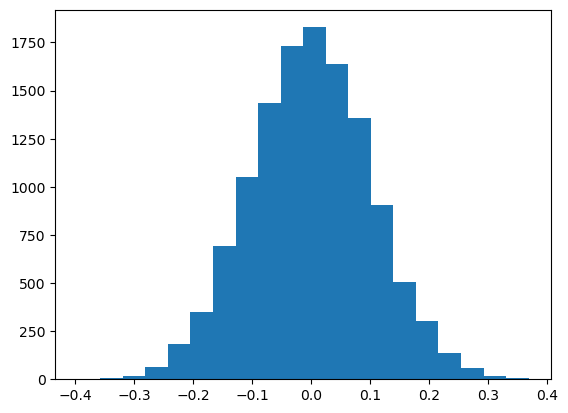

In [66]:
tensor = model.transformer_layers[1].valueMatrix.data[0]
print(tensor.shape)
print(torch.std(tensor))
plt.hist(tensor.flatten().detach().numpy(), bins=20)

In [182]:
outp.shape

torch.Size([64, 5, 128, 128])